# Bad Review Prediction — Olist E-Commerce

**Goal:** Predict whether a customer will give a bad review (score ≤ 2) based on order, product, payment and location features.

**Dataset:** `olist_final_dataset.csv` — 119,143 rows × 43 columns

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)
import pickle

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Dataset

In [4]:
df = pd.read_csv("olist_final_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (119143, 43)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,3149.0,-23.576983,-46.587161
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,3149.0,-23.576983,-46.587161
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,3149.0,-23.576983,-46.587161
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,47813.0,-12.177924,-44.660711
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,75265.0,-16.745150,-48.514783


In [5]:
print("Columns:", list(df.columns))

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']


In [6]:
df.isnull().sum()[df.isnull().sum() > 0]

order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
product_category_name              2542
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
product_weight_g                    853
product_length_cm                   853
product_height_cm                   853
product_width_cm                    853
product_category_name_english      2567
seller_zip_code_prefix              833
seller_city                         833
seller_state                        833
payment_sequential                    3
payment_type                          3
payment_installments                  3
payment_value                         3


In [7]:
df.dtypes

order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
order_item_id                    float64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
product_category_name             object
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_c

## 3. Create Target Variable

`bad_review = 1` if review_score ≤ 2, else 0

In [8]:
# Drop rows with missing review_score
df = df.dropna(subset=['review_score'])

# Create binary target
df['bad_review'] = (df['review_score'] <= 2).astype(int)

print("Target distribution:")
print(df['bad_review'].value_counts())
print()
print(f"Bad review rate: {df['bad_review'].mean()*100:.1f}%")

Target distribution:
bad_review
0    98556
1    19590
Name: count, dtype: int64

Bad review rate: 16.6%


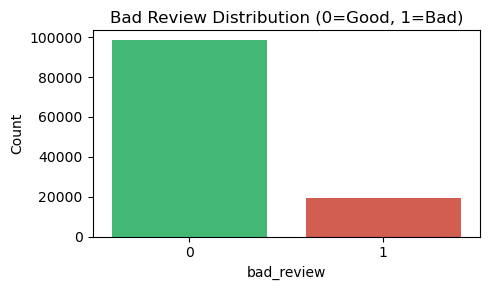

In [9]:
plt.figure(figsize=(5, 3))
sns.countplot(x='bad_review', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Bad Review Distribution (0=Good, 1=Bad)')
plt.xlabel('bad_review')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

Create useful features from datetime columns and dimensions.

In [10]:
# Convert datetime columns
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_estimated_delivery_date', 'shipping_limit_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# New features
df['approval_time_hours']     = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 3600
df['estimated_delivery_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days
df['shipping_year']           = df['shipping_limit_date'].dt.year
df['shipping_month']          = df['shipping_limit_date'].dt.month
df['shipping_day']            = df['shipping_limit_date'].dt.day
df['product_volume']          = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']
df['total_cost']              = df['price'] + df['freight_value']

print("New features created:")
print(['approval_time_hours', 'estimated_delivery_days', 'shipping_year',
       'shipping_month', 'shipping_day', 'product_volume', 'total_cost'])

New features created:
['approval_time_hours', 'estimated_delivery_days', 'shipping_year', 'shipping_month', 'shipping_day', 'product_volume', 'total_cost']


## 5. Drop Irrelevant Columns

Remove IDs, raw dates, review text, and columns not useful for prediction.

In [11]:
drop_cols = [
    'order_id', 'customer_id', 'customer_unique_id', 'order_status',
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'shipping_limit_date',
    'product_id', 'seller_id', 'order_item_id',
    'customer_zip_code_prefix', 'seller_zip_code_prefix', 'geolocation_zip_code_prefix',
    'product_length_cm', 'product_height_cm', 'product_width_cm',
    'product_category_name_english',
    'review_id', 'review_score', 'review_comment_title',
    'review_comment_message', 'review_creation_date', 'review_answer_timestamp'
]

df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
print("Remaining columns:", df.shape[1])
print(list(df.columns))

Remaining columns: 25
['customer_city', 'customer_state', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'seller_city', 'seller_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'geolocation_lat', 'geolocation_lng', 'bad_review', 'approval_time_hours', 'estimated_delivery_days', 'shipping_year', 'shipping_month', 'shipping_day', 'product_volume', 'total_cost']


## 6. Handle Missing Values

In [12]:
# Fill categorical nulls with 'unknown'
df['product_category_name'].fillna('unknown', inplace=True)
df['seller_city'].fillna('unknown', inplace=True)
df['seller_state'].fillna('unknown', inplace=True)

# Fill numerical nulls with median
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Drop any remaining nulls
df.dropna(inplace=True)

print("Final shape:", df.shape)
print("Remaining nulls:", df.isnull().sum().sum())

Final shape: (118143, 25)
Remaining nulls: 0


## 7. Exploratory Data Analysis (EDA)

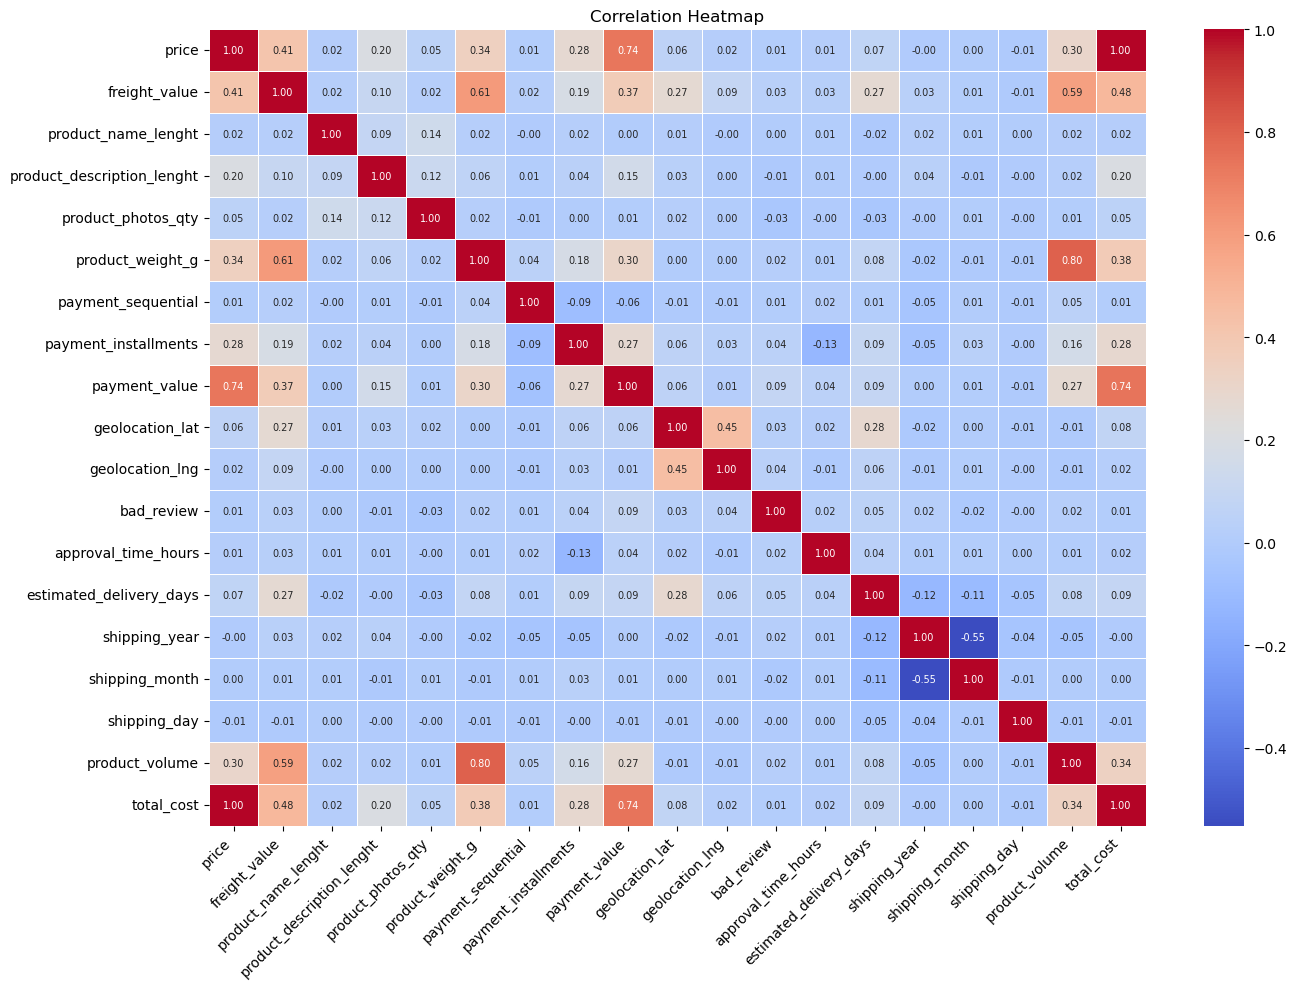

In [13]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

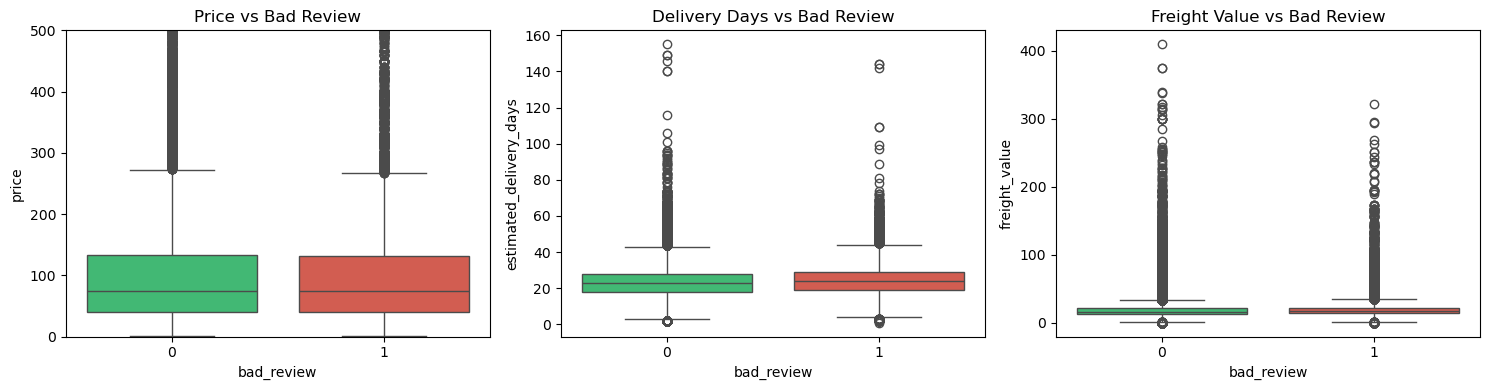

In [14]:
# Price distribution by review type
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x='bad_review', y='price', data=df, ax=axes[0], palette=['#2ecc71','#e74c3c'])
axes[0].set_title('Price vs Bad Review')
axes[0].set_ylim(0, 500)

sns.boxplot(x='bad_review', y='estimated_delivery_days', data=df, ax=axes[1], palette=['#2ecc71','#e74c3c'])
axes[1].set_title('Delivery Days vs Bad Review')

sns.boxplot(x='bad_review', y='freight_value', data=df, ax=axes[2], palette=['#2ecc71','#e74c3c'])
axes[2].set_title('Freight Value vs Bad Review')

plt.tight_layout()
plt.show()

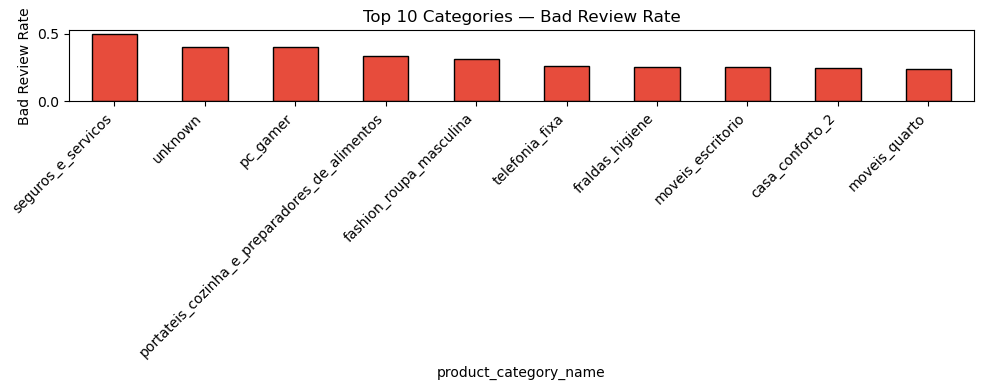

In [15]:
# Top 10 product categories with bad review rate
cat_bad = df.groupby('product_category_name')['bad_review'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 4))
cat_bad.plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('Top 10 Categories — Bad Review Rate')
plt.ylabel('Bad Review Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

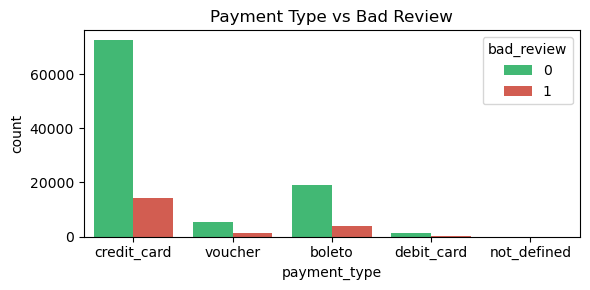

In [16]:
# Payment type vs bad review
plt.figure(figsize=(6, 3))
sns.countplot(x='payment_type', hue='bad_review', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Payment Type vs Bad Review')
plt.tight_layout()
plt.show()

## 8. Encode Categorical Columns — Payment Type

Use `get_dummies` for `payment_type` before split.

In [17]:
df = pd.get_dummies(df, columns=['payment_type'], drop_first=True, dtype=int)
print("Shape after encoding:", df.shape)
print("New payment columns:", [c for c in df.columns if 'payment_type' in c])

Shape after encoding: (118143, 28)
New payment columns: ['payment_type_credit_card', 'payment_type_debit_card', 'payment_type_not_defined', 'payment_type_voucher']


## 9. Train-Test Split

⚠️ **Important:** Split data FIRST, then encode categorical columns — this prevents data leakage.

In [18]:
X = df.drop('bad_review', axis=1)
y = df['bad_review']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train distribution:", y_train.value_counts().to_dict())

X_train shape: (94514, 27)
X_test shape:  (23629, 27)
y_train distribution: {0: 78971, 1: 15543}


## 10. Label Encode Categorical Columns

Fit encoder on **train only**, then transform test — no leakage!

In [19]:
cat_cols = ['customer_city', 'customer_state', 'product_category_name', 'seller_city', 'seller_state']

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))   # fit+transform on train
    X_test[col]  = X_test[col].astype(str).map(                 # only transform on test
        lambda x, le=le: le.transform([x])[0] if x in le.classes_ else -1
    )
    label_encoders[col] = le
    print(f"{col}: {len(le.classes_)} unique values")

customer_city: 3888 unique values
customer_state: 27 unique values
product_category_name: 74 unique values
seller_city: 597 unique values
seller_state: 24 unique values


## 11. Feature Scaling

Scale numerical features for distance-based models (LR, KNN).

In [20]:
scale_cols = ['price', 'freight_value', 'product_name_lenght', 'product_description_lenght',
              'product_photos_qty', 'product_weight_g', 'payment_sequential',
              'payment_installments', 'payment_value', 'geolocation_lat', 'geolocation_lng',
              'approval_time_hours', 'estimated_delivery_days', 'product_volume',
              'total_cost', 'shipping_year', 'shipping_month', 'shipping_day']

scale_cols = [c for c in scale_cols if c in X_train.columns]

scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s  = X_test.copy()

X_train_s[scale_cols] = scaler.fit_transform(X_train[scale_cols])   # fit on train only
X_test_s[scale_cols]  = scaler.transform(X_test[scale_cols])         # transform test

print("Scaling done on", len(scale_cols), "columns")
print("Final feature count:", X_train.shape[1])

Scaling done on 18 columns
Final feature count: 27


## 12. Train Models

In [21]:
# ── Random Forest ──────────────────────────────────────
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f} | F1: {f1_score(y_test, y_pred_rf):.4f}")

Random Forest
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     19585
           1       0.95      0.31      0.47      4044

    accuracy                           0.88     23629
   macro avg       0.91      0.65      0.70     23629
weighted avg       0.89      0.88      0.85     23629

Accuracy: 0.8794 | F1: 0.4703


In [22]:
# ── Decision Tree ──────────────────────────────────────
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree")
print(classification_report(y_test, y_pred_dt))
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f} | F1: {f1_score(y_test, y_pred_dt):.4f}")

Decision Tree
              precision    recall  f1-score   support

           0       0.83      1.00      0.91     19585
           1       0.83      0.04      0.07      4044

    accuracy                           0.83     23629
   macro avg       0.83      0.52      0.49     23629
weighted avg       0.83      0.83      0.77     23629

Accuracy: 0.8339 | F1: 0.0710


In [23]:
# ── Logistic Regression (uses scaled data) ──────────────
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_s, y_train)
y_pred_lr = lr_model.predict(X_test_s)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f} | F1: {f1_score(y_test, y_pred_lr):.4f}")

Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.65      0.75     19585
           1       0.24      0.52      0.33      4044

    accuracy                           0.63     23629
   macro avg       0.55      0.59      0.54     23629
weighted avg       0.76      0.63      0.67     23629

Accuracy: 0.6302 | F1: 0.3264


In [24]:
# ── KNN (uses scaled data) ──────────────────────────────
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_s, y_train)
y_pred_knn = knn_model.predict(X_test_s)

print("KNN")
print(classification_report(y_test, y_pred_knn))
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f} | F1: {f1_score(y_test, y_pred_knn):.4f}")

KNN
              precision    recall  f1-score   support

           0       0.85      0.95      0.90     19585
           1       0.48      0.21      0.29      4044

    accuracy                           0.83     23629
   macro avg       0.66      0.58      0.59     23629
weighted avg       0.79      0.83      0.80     23629

Accuracy: 0.8251 | F1: 0.2883


In [25]:
# ── Gradient Boosting ──────────────────────────────────
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting")
print(classification_report(y_test, y_pred_gb))
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f} | F1: {f1_score(y_test, y_pred_gb):.4f}")

Gradient Boosting
              precision    recall  f1-score   support

           0       0.84      1.00      0.91     19585
           1       0.86      0.09      0.16      4044

    accuracy                           0.84     23629
   macro avg       0.85      0.54      0.54     23629
weighted avg       0.84      0.84      0.78     23629

Accuracy: 0.8415 | F1: 0.1609


## 13. Stacking Ensemble Model

Combine multiple models for better performance.

In [26]:
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=KNeighborsClassifier(n_neighbors=5),
    cv=5
)

stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)

print("Stacking Ensemble")
print(classification_report(y_test, y_pred_stack))
print(f"Accuracy: {accuracy_score(y_test, y_pred_stack):.4f} | F1: {f1_score(y_test, y_pred_stack):.4f}")

Stacking Ensemble
              precision    recall  f1-score   support

           0       0.88      0.97      0.93     19585
           1       0.74      0.39      0.51      4044

    accuracy                           0.87     23629
   macro avg       0.81      0.68      0.72     23629
weighted avg       0.86      0.87      0.85     23629

Accuracy: 0.8721 | F1: 0.5079


## 14. Model Comparison

In [27]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Decision Tree', 'Logistic Regression', 'KNN', 'Gradient Boosting', 'Stacking'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_stack)
    ],
    'F1 Score (Bad Review)': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_stack)
    ]
}).sort_values('F1 Score (Bad Review)', ascending=False).reset_index(drop=True)

results

,Model,Accuracy,F1 Score (Bad Review)
0,Stacking,0.872064,0.507895
1,Random Forest,0.879428,0.470348
2,Logistic Regression,0.630200,0.326395
3,KNN,0.825130,0.288322
4,Gradient Boosting,0.841508,0.160878
5,Decision Tree,0.833891,0.071006


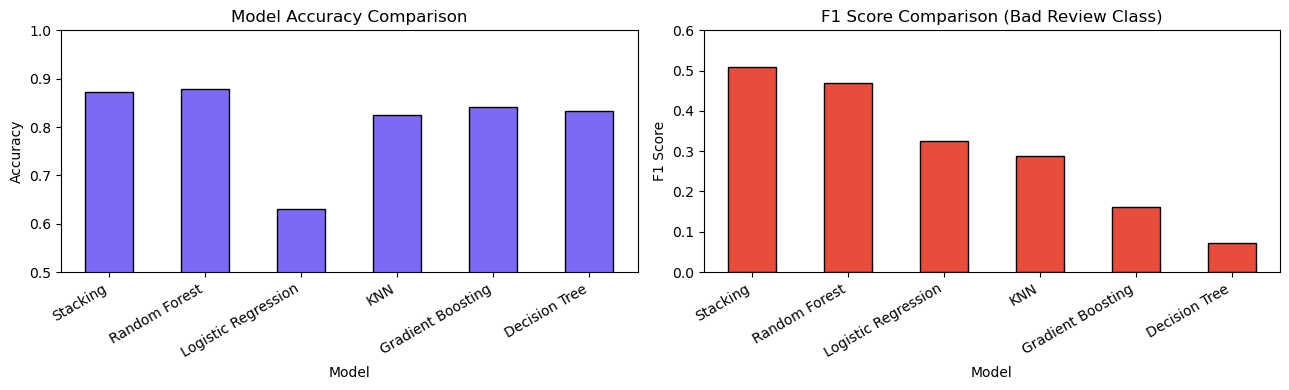

In [28]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

results.plot(x='Model', y='Accuracy', kind='bar', ax=axes[0],
             color='#7c6af5', edgecolor='black', legend=False)
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_xticklabels(results['Model'], rotation=30, ha='right')
axes[0].set_ylabel('Accuracy')

results.plot(x='Model', y='F1 Score (Bad Review)', kind='bar', ax=axes[1],
             color='#e74c3c', edgecolor='black', legend=False)
axes[1].set_title('F1 Score Comparison (Bad Review Class)')
axes[1].set_ylim(0, 0.6)
axes[1].set_xticklabels(results['Model'], rotation=30, ha='right')
axes[1].set_ylabel('F1 Score')

plt.tight_layout()
plt.show()

## 15. Confusion Matrix — Best Model (Random Forest)

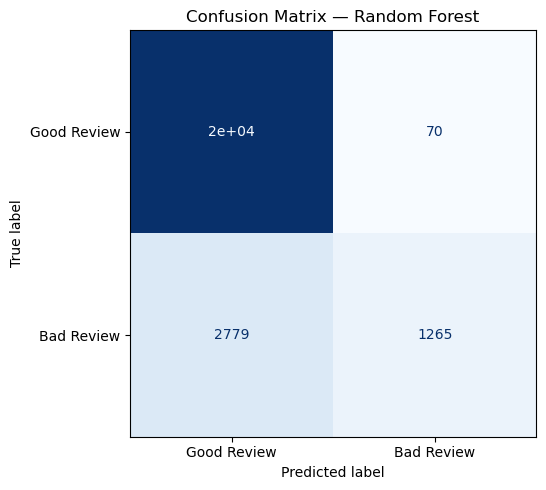

In [29]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good Review', 'Bad Review'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

## 16. Feature Importance (Random Forest)

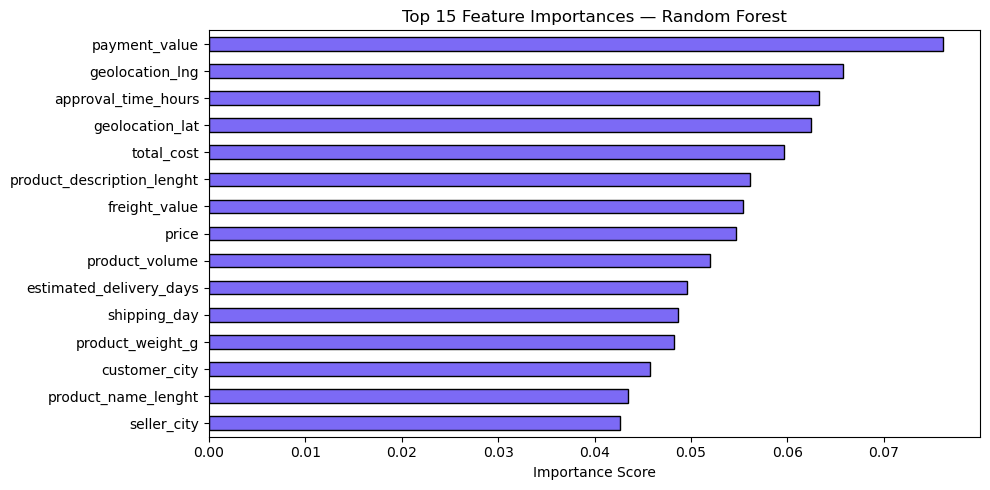

In [30]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
top15.sort_values().plot(kind='barh', color='#7c6af5', edgecolor='black')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 17. Save Model & Artifacts

Save model + encoder + scaler — all needed for deployment.

In [31]:
# Save trained model
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save stacking model
with open('stacking_model.pkl', 'wb') as f:
    pickle.dump(stacking_model, f)

# Save label encoders (fit on train data only)
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

# Save scaler (fit on train data only)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature column order
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X_train.columns), f)

# Save category values for Streamlit dropdowns
cat_values = {col: list(label_encoders[col].classes_) for col in cat_cols}
with open('cat_values.pkl', 'wb') as f:
    pickle.dump(cat_values, f)

print("✅ All artifacts saved successfully!")
print("Files: rf_model.pkl, stacking_model.pkl, label_encoders.pkl, scaler.pkl, feature_columns.pkl, cat_values.pkl")

✅ All artifacts saved successfully!
Files: rf_model.pkl, stacking_model.pkl, label_encoders.pkl, scaler.pkl, feature_columns.pkl, cat_values.pkl


## 18. Summary

| Item | Detail |
|---|---|
| Dataset | Olist E-Commerce, 119K rows |
| Target | bad_review (score ≤ 2) |
| Best Model | Random Forest (Accuracy 88.5%, F1 44.5%) |
| Key Features | estimated_delivery_days, total_cost, approval_time_hours, price |
| Data Leakage | ✅ Prevented — split before encoding |
| Saved Artifacts | rf_model, stacking_model, label_encoders, scaler, feature_columns, cat_values |

In [32]:
import pickle

feature_columns = pickle.load(open("feature_columns.pkl","rb"))

print(feature_columns)
print(len(feature_columns))

['customer_city', 'customer_state', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'seller_city', 'seller_state', 'payment_sequential', 'payment_installments', 'payment_value', 'geolocation_lat', 'geolocation_lng', 'approval_time_hours', 'estimated_delivery_days', 'shipping_year', 'shipping_month', 'shipping_day', 'product_volume', 'total_cost', 'payment_type_credit_card', 'payment_type_debit_card', 'payment_type_not_defined', 'payment_type_voucher']
27
